# Perforamnce Analytics

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy.stats import linregress 

In [6]:
nav = pd.read_csv('../data/raw/02_nav_history.csv')
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
performance  = pd.read_csv("../data/raw/07_scheme_performance.csv")

In [7]:
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [16]:
nav = nav.sort_values(['amfi_code','date'])
nav['daily_returns'] = nav.groupby('amfi_code')['nav'].pct_change()


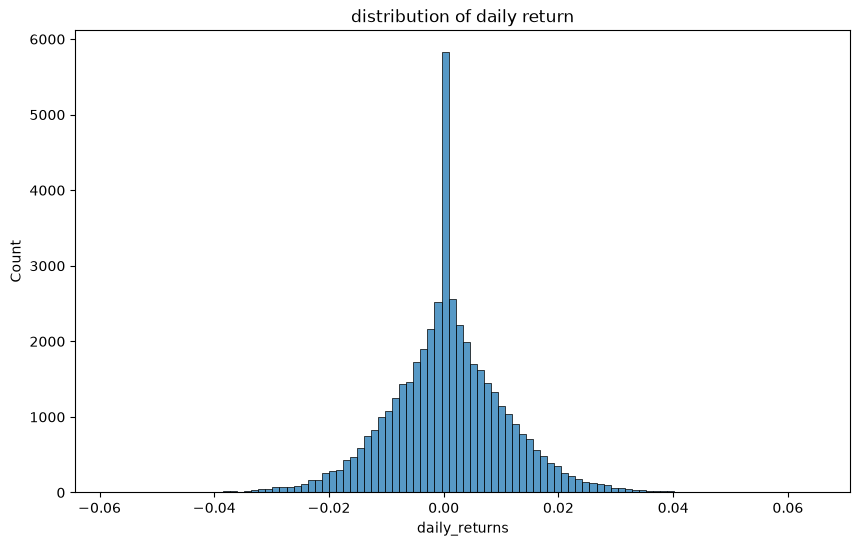

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(nav['daily_returns'].dropna(),bins=100)
plt.title('distribution of daily return')
plt.show()

In [20]:
def calculate_cagr(df, years):

    result = []

    for fund in df['amfi_code'].unique():

        fund_df = (
            df[df['amfi_code']==fund]
            .sort_values('date')
        )

        end_date = fund_df['date'].max()

        start_date = (
            end_date -
            pd.DateOffset(years=years)
        )

        temp = fund_df[
            fund_df['date'] >= start_date
        ]

        if len(temp) < 2:
            continue

        start_nav = temp.iloc[0]['nav']
        end_nav = temp.iloc[-1]['nav']

        cagr = (
            (end_nav/start_nav)
            **(1/years)
            -1
        )

        result.append(
            [fund,cagr]
        )

    return pd.DataFrame(
        result,
        columns=[
            'amfi_code',
            f'cagr_{years}yr'
        ]
    )

In [21]:
cagr1 = calculate_cagr(nav,1)

cagr3 = calculate_cagr(nav,3)

cagr5 = calculate_cagr(nav,5)

cagr_table = (
    cagr1
    .merge(cagr3,on='amfi_code')
    .merge(cagr5,on='amfi_code')
)

cagr_table.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [23]:
RF = 0.065
sharpe_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    mean_return = (
        temp['daily_returns']
        .mean()
    )

    std_return = (
        temp['daily_returns']
        .std()
    )

    sharpe = (
        (mean_return - RF/252)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [25]:
sortino_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    mean_return = (
        temp['daily_returns']
        .mean()
    )

    downside = temp[
        temp['daily_returns'] < 0
    ]['daily_returns']

    downside_std = downside.std()

    sortino = (
        (mean_return - RF/252)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

In [27]:
sortino_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    mean_return = (
        temp['daily_returns']
        .mean()
    )

    downside = temp[
        temp['daily_returns'] < 0
    ]['daily_returns']

    downside_std = downside.std()

    sortino = (
        (mean_return - RF/252)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

In [31]:
alpha_beta = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ][['date','daily_returns']]

    merged = (
        temp.merge(
            benchmark[
                ['date',
                 'close_value']
            ],
            on='date'
        )
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, se = (
        linregress(
            merged['close_value'],
            merged['daily_returns']
        )
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [fund,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

In [32]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [33]:
mdd_results = []

for fund in nav['amfi_code'].unique():

    temp = (
        nav[
            nav['amfi_code']==fund
        ]
        .sort_values('date')
    )

    running_max = (
        temp['nav']
        .cummax()
    )

    drawdown = (
        temp['nav']
        /
        running_max
        -1
    )

    mdd = drawdown.min()

    mdd_results.append(
        [fund,mdd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

In [34]:
scorecard = (
    cagr3
    .merge(
        sharpe_df,
        on='amfi_code'
    )
    .merge(
        alpha_beta_df,
        on='amfi_code'
    )
    .merge(
        mdd_df,
        on='amfi_code'
    )
)

In [35]:
scorecard['return_rank'] = (
    scorecard['cagr_3yr']
    .rank(pct=True)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(pct=True)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(pct=True)
)

scorecard['dd_rank'] = (
    (-scorecard['max_drawdown'])
    .rank(pct=True)
)

In [36]:
scorecard['fund_score'] = (

      30 * scorecard['return_rank']

    + 25 * scorecard['sharpe_rank']

    + 20 * scorecard['alpha_rank']

    + 10 * scorecard['dd_rank']

)

In [38]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [39]:
top5 = (
    scorecard
    .sort_values(
        'fund_score',
        ascending=False
    )
    .head(5)
    ['amfi_code']
)

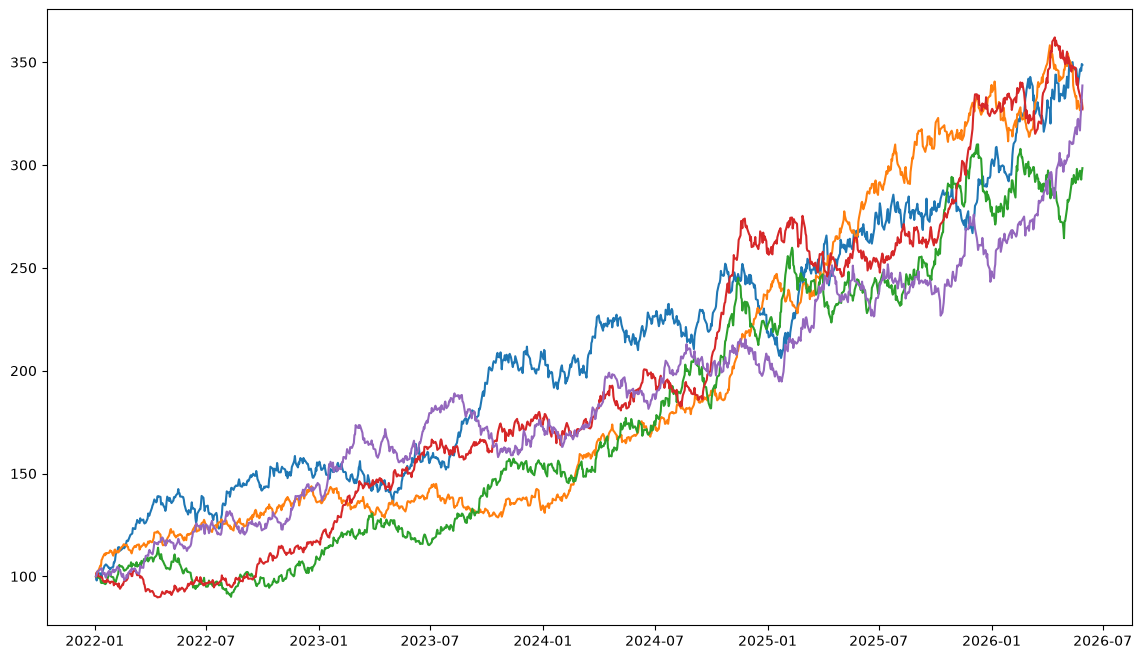

In [40]:
plt.figure(figsize=(14,8))

for fund in top5:

    temp = nav[
        nav['amfi_code']==fund
    ]

    growth = (
        temp['nav']
        /
        temp['nav'].iloc[0]
        *100
    )

    plt.plot(
        temp['date'],
        growth,
        label=str(fund)
    )

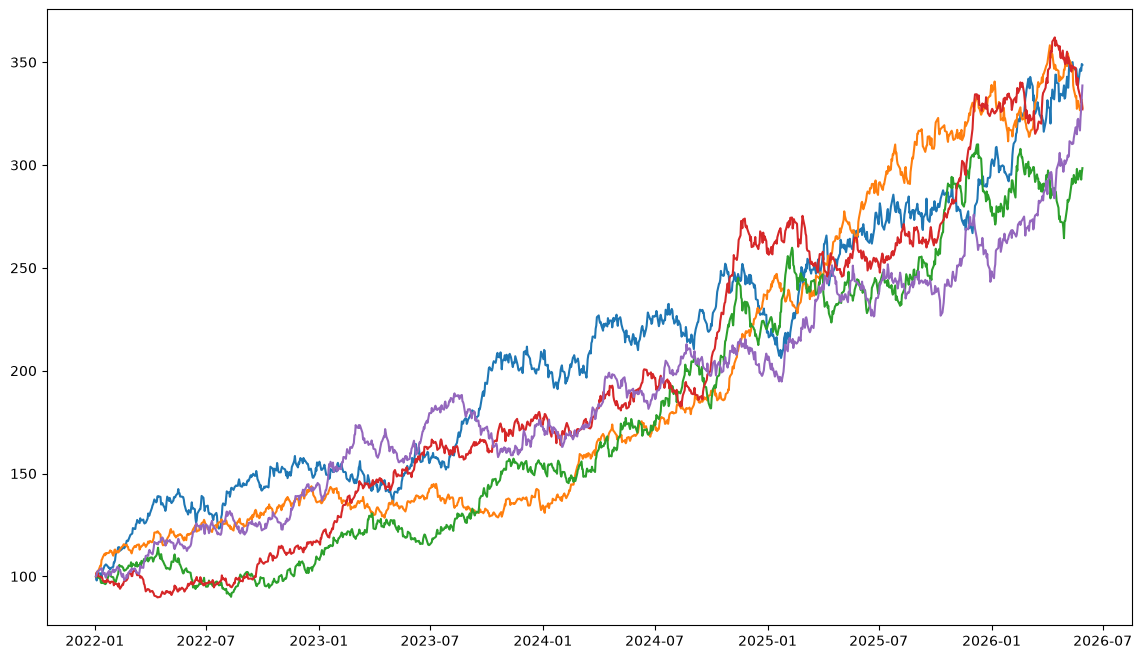

In [41]:
plt.figure(figsize=(14,8))

for fund in top5:

    temp = nav[
        nav['amfi_code']==fund
    ]

    growth = (
        temp['nav']
        /
        temp['nav'].iloc[0]
        *100
    )

    plt.plot(
        temp['date'],
        growth,
        label=str(fund)
    )

In [44]:
tracking_errors = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ][['date','daily_returns']]

    merged = (
        temp.merge(
            benchmark[
                ['date',
                 'close_value']
            ],
            on='date'
        )
    )

    diff = (
        merged['daily_returns']
        -
        merged['close_value']
    )

    te = (
        diff.std()
        *
        np.sqrt(252)
    )

    tracking_errors.append(
        [fund,te]
    )

tracking_df = pd.DataFrame(
    tracking_errors,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_df.head()

,amfi_code,tracking_error
0,100016,224990.886455
1,100025,224990.886131
2,100033,224990.884935
3,101206,224990.883928
4,101207,224990.889585
